<a href="https://colab.research.google.com/github/Jayakrishna143/portfolio-project/blob/main/cars_inside.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd,numpy as np ,requests
from bs4 import BeautifulSoup
from tqdm import tqdm

### Urls of Websites Each for Each city


In [ ]:
# List of URLs
urls = [
    "https://www.cars24.com/buy-used-car/?sort=bestmatch&serveWarrantyCount=true&listingSource=Homepage_Filters&storeCityId=1",
    "https://www.cars24.com/buy-used-cars-ahmedabad/?sort=bestmatch&serveWarrantyCount=true&storeCityId=1692",
    "https://www.cars24.com/buy-used-cars-hyderabad/?sort=bestmatch&serveWarrantyCount=true&storeCityId=3686",
    "https://www.cars24.com/buy-used-cars-mumbai/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2378",
    "https://www.cars24.com/buy-used-cars-bangalore/?sort=bestmatch&serveWarrantyCount=true&storeCityId=4709",
    "https://www.cars24.com/buy-used-cars-chennai/?sort=bestmatch&serveWarrantyCount=true&storeCityId=5732",
    "https://www.cars24.com/buy-used-cars-pune/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2423",
    "https://www.cars24.com/buy-used-cars-new-delhi/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2",
    "https://www.cars24.com/buy-used-cars-noida/?sort=bestmatch&serveWarrantyCount=true&storeCityId=134",
    "https://www.cars24.com/buy-used-cars-ghaziabad/?sort=bestmatch&serveWarrantyCount=true&storeCityId=132",
    "https://www.cars24.com/buy-used-cars-lucknow/?sort=bestmatch&serveWarrantyCount=true&storeCityId=290",
    "https://www.cars24.com/buy-used-cars-jaipur/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2130",
    "https://www.cars24.com/buy-used-cars-kolkata/?sort=bestmatch&serveWarrantyCount=true&storeCityId=777",
    "https://www.cars24.com/buy-used-cars-kochi/?sort=bestmatch&serveWarrantyCount=true&storeCityId=6356",
    "https://www.cars24.com/buy-used-cars-nashik/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2598",
    "https://www.cars24.com/buy-used-cars-coimbatore/?sort=bestmatch&serveWarrantyCount=true&storeCityId=6105",
    "https://www.cars24.com/buy-used-cars-indore/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2920",
    "https://www.cars24.com/buy-used-cars-patna/?sort=bestmatch&serveWarrantyCount=true&storeCityId=8184",
    "https://www.cars24.com/buy-used-cars-surat/?sort=bestmatch&serveWarrantyCount=true&storeCityId=1605",
    "https://www.cars24.com/buy-used-cars-chandigarh/?sort=bestmatch&serveWarrantyCount=true&storeCityId=769",
    "https://www.cars24.com/buy-used-cars-ludhiana/?sort=bestmatch&serveWarrantyCount=true&storeCityId=666",
    "https://www.cars24.com/buy-used-cars-rajkot/?sort=bestmatch&serveWarrantyCount=true&storeCityId=1606",
    "https://www.cars24.com/buy-used-cars-vadodara/?sort=bestmatch&serveWarrantyCount=true&storeCityId=1674",
    "https://www.cars24.com/buy-used-cars-agra/?sort=bestmatch&serveWarrantyCount=true&storeCityId=136",
    "https://www.cars24.com/buy-used-cars-bhopal/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2987",
    "https://www.cars24.com/buy-used-cars-kota/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2234",
    "https://www.cars24.com/buy-used-cars-amritsar/?sort=bestmatch&serveWarrantyCount=true&storeCityId=684",
    'https://www.cars24.com/buy-used-cars-chandigarh-tricity/?sort=bestmatch&serveWarrantyCount=true&storeCityId=8623',
    "https://www.cars24.com/buy-used-cars-gurgaon/?sort=bestmatch&serveWarrantyCount=true&storeCityId=5",
    "https://www.cars24.com/buy-used-cars-nagpur/?sort=bestmatch&serveWarrantyCount=true&storeCityId=2713"
]

In [ ]:
# len(urls)

## Scrapping data

### scrapping data from urls given

In [ ]:
all_dfs = []

for url in tqdm(urls):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html")

# selecting all the data with div as styles_outer__NTVTH
    a_data = soup.select('div.styles_outer__NTVth')

# all the data is cleaned into text and stored into title and alldata
    titles = []
    alldata = []
    for item in a_data:
        titles.append(item.find('span').text)
        alldata.append(item.find_all('p'))
    data = []
    for group in alldata:
        for element in group:
            data.append(element.text)

# in all_data,the recods are in one list so creating a sublists for each row
    sublists = []
    temp_list = []
    for item in data:
        if item == "+ other charges":
            sublists.append(temp_list)
            temp_list = []
        else:
            temp_list.append(item)


    # Creating a DataFrame for car titles
    df = pd.DataFrame(titles, columns=['Cars'])

    # Extracting the brand name from the car title
    brands = []
    for car in df['Cars']:
        parts = car.split(" ")
        if len(parts) > 1:
            brands.append(parts[1])
        else:
            brands.append(None)
    df['Brand'] = brands

    # Creating a DataFrame from the sublists.
    df2 = pd.DataFrame(sublists, columns=['total_km_k', 'Fueltype', 'enginetype', 'owner_type', 'EMI_₹', 'price_lks', 'disc_price_lks'])

    # Mergeing the two DataFrames using the index
    merged_df = pd.merge(df, df2, left_index=True, right_index=True)

    merged_df['URL'] = url # adding url as a column

    # Append the merged DataFrame to the list
    all_dfs.append(merged_df)
cars = pd.concat(all_dfs, ignore_index=True)

100%|██████████| 30/30 [00:45<00:00,  1.51s/it]


#### Clearing cars data

In [ ]:
cars["EMI_₹"] = cars["EMI_₹"].str.replace(r"[^\d]", "", regex=True).astype(int)
cars["price_lks"] = cars["price_lks"].str.extract(r"(\d+\.\d+)").astype(float)
cars["disc_price_lks"] = cars["disc_price_lks"].str.extract(r"(\d+\.\d+)").astype(float)
cars['total_km_k'] = cars['total_km_k'].str.extract(r"(\d+\.\d+)").astype(float)

In [ ]:
cars

,Cars,Brand,total_km_k,Fueltype,enginetype,owner_type,EMI_₹,price_lks,disc_price_lks,URL
0,2024 Nissan MAGNITE,Nissan,3.20,Petrol,Auto,1st owner,11926,6.22,6.10,https://www.cars24.com/buy-used-car/?sort=best...
1,2018 Hyundai Elite i20,Hyundai,98.69,Petrol,Manual,1st owner,7657,4.74,3.92,https://www.cars24.com/buy-used-car/?sort=best...
2,2021 Maruti Ciaz,Maruti,33.73,Petrol,Manual,1st owner,12776,7.38,6.53,https://www.cars24.com/buy-used-car/?sort=best...
3,2017 Skoda Rapid,Skoda,36.85,Petrol,Manual,2nd owner,10362,5.59,5.30,https://www.cars24.com/buy-used-car/?sort=best...
4,2020 Skoda Rapid,Skoda,44.65,Petrol,Manual,1st owner,12258,6.27,NaN,https://www.cars24.com/buy-used-car/?sort=best...
...,...,...,...,...,...,...,...,...,...,...
495,2021 Renault Kwid,Renault,20.26,Petrol,Manual,1st owner,7122,3.91,3.64,https://www.cars24.com/buy-used-cars-nagpur/?s...
496,2022 Maruti Vitara Brezza,Maruti,53.97,Petrol,Manual,1st owner,15519,8.55,7.94,https://www.cars24.com/buy-used-cars-nagpur/?s...
497,2015 Hyundai Xcent,Hyundai,75.95,Petrol,Manual,1st owner,8230,4.13,3.70,https://www.cars24.com/buy-used-cars-nagpur/?s...
498,2019 Mahindra XUV300,Mahindra,97.36,Petrol,Manual,1st owner,13138,6.72,NaN,https://www.cars24.com/buy-used-cars-nagpur/?s...


In [ ]:
cars.to_csv('cars24_cleaned1.csv',index = False )

### Scrapping data inside a link specific or each car

In [ ]:
links = []
for  url in tqdm(urls):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    for div in soup.find_all('div', class_='styles_wrapper__b4UUV'):
        a_tags = div.find_all('a', href=True)
        if a_tags:
            for i in a_tags:
                link = i.get('href')
                links.append(link)
all_data = []
all_car_name = []
all_price = []
all_emi = []
counts = 0
for link in tqdm(links):
    response_in = requests.get(link,'html')
    soup_in = BeautifulSoup(response_in.text,"html.parser")
    ul_data = soup_in.find("ul",class_='styles_content__KtXDs')
    x = soup_in.find('p', class_='sc-braxZu fjhfdl')
    if x: # code goes further only if it find the title
        all_car_name.append(x.text)
        y = soup_in.find('div', class_='styles_price__3yE9i')
        if y:
            all_price.append(y.text)
        else:
            all_price.append(np.nan)
            print('y.none')

        z = soup_in.find('p', class_='sc-braxZu iamGuN')
        if z :
            all_emi.append(z.text)
        else :
            all_emi.append(np.nan)
            print('z.none')
        data = [i.text if ul_data else [np.nan]*11 for i in ul_data]
        all_data.append((data + [np.nan] * (11 - len(data)))[:11])
    else:
        counts+=1

 37%|███▋      | 11/30 [00:21<00:36,  1.91s/it]
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-4-810e71a3310d>", line 4, in <cell line: 0>
    soup = BeautifulSoup(response.text, "html.parser")
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/bs4/__init__.py", line 473, in __init__
    self._feed()
  File "/usr/local/lib/python3.11/dist-packages/bs4/__init__.py", line 658, in _feed
    self.builder.feed(self.markup)
  File "/usr/local/lib/python3.11/dist-packages/bs4/builder/_htmlparser.py", line 467, in feed
    parser.feed(markup)
  File "/usr/lib/python3.11/html/parser.py", line 110, in feed
    self.goahead(0)
  File "/usr/lib/python3.11/html/parser.py", line 170, in goahead
    k = self.parse_starttag(i)
        ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/html/parser.py", line 337, in parse_starttag


In [ ]:
counts

0

In [ ]:
df = pd.DataFrame(all_data,columns=['Reg_year','Fuel','KM_driven','Transmission','Engine_capacity_CC','Ownership','Make_year','Spare_key','Reg_number','Insurance','Insurance_type'])
df2 = pd.DataFrame({'car_name': all_car_name,
                   'price': all_price,
                   'EMI_k' : all_emi})
result=df2.merge(df, left_index=True, right_index=True)

## saving the raw_dataframe

In [ ]:
result.to_csv('CARS24raw.csv',index = False)


## Cleaning result dataframe

In [ ]:
result['Ownership'] = result['Ownership'].str.replace(r"[^\d]", "", regex=True).astype(int)

In [ ]:
rows_to_delete = []
count=0
for i, j in enumerate(result.Ownership):
    if j in [1, 2, 3]:
        count+=1
    else:
        rows_to_delete.append(i)  # Append the index if you want to delete by index


In [ ]:
result = result.drop(rows_to_delete)

In [ ]:
result['price'] = [(i.split()[0].replace('₹','')) for i in result['price']]
result['price'] = (result['price'].astype(float)  * 100000).astype(int)
result["EMI_k"] = result["EMI_k"].str.replace(r"[^\d]", "", regex=True).astype(float)
result["Reg_year"] = result["Reg_year"].str.replace(r"[^\d]", "", regex=True).astype(int)
result['Fuel']= result['Fuel'].str.replace('Fuel','')
result["KM_driven"] = result["KM_driven"].str.replace(r"[^\d]", "", regex=True).astype(int)
result['Transmission'] = result['Transmission'].str.replace("Transmission",'')
result["Make_year"] = result["Make_year"].str.replace(r"[^\d]", "", regex=True)
result['Engine_capacity_CC'] = result['Engine_capacity_CC'].str.replace(r"[^\d]", "", regex=True).astype(int)
result['Spare_key'] = result['Spare_key'].str.replace("Spare key",'')
result['Insurance'] = ['no' if x == 'Insurance Need renewal' else 'yes' for x in result['Insurance']]
result.insert(1, 'Brand', [i.split()[1] for i in result['car_name']])

In [ ]:
result.insert(6, 'Avg CC', result.groupby('Brand')['Engine_capacity_CC'].transform('mean'))

In [ ]:
result.insert(11, 'Avg price', result.groupby('Brand')['price'].transform('mean'))
result.insert(13,'car_age',2025 - result['Make_year'].astype(int))

In [ ]:
result = result[result['price'] <= 2000000]

NameError: name 'result' is not defined

In [ ]:
result.to_csv('CARS24_CLEANED.csv',index = False)

NameError: name 'result' is not defined

In [ ]:
!pip install pyjanitor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 7.9 MB/s eta 0:00:00


## Analysing the data

In [ ]:
A_data = pd.read_csv('/content/CARS24_CLEANED (1).csv')

In [ ]:
import janitor
A_data = A_data.clean_names()

In [ ]:
A_data.head()

,car_name,brand,price,emi_k,reg_year,fuel,avg_cc,km_driven,transmission,engine_capacity_cc,ownership,avg_price,make_year,car_age,spare_key,reg_number,insurance,insurance_type
0,2017 Tata TIGOR XZ (O) PETROL,Tata,325000,6354.0,2017,Petrol,1242.550000,85992,Manual,1199,1,551116.633333,2017,8,No,Reg number DL3C**1750,no,"Insurance type Plans from ₹3,796/y"
1,2024 Nissan MAGNITE XE AMT EZ Shift,Nissan,610000,11926.0,2024,Petrol,1040.312500,3200,Automatic,999,1,516437.375000,2024,1,No,Reg number DL3C**9013,no,"Insurance type Plans from ₹2,474/y"
2,2021 Maruti Ciaz DELTA 1.5 SHVS MT PETROL,Maruti,653000,12776.0,2021,Petrol,1128.668790,33730,Manual,1462,1,435796.108280,2021,4,Yes,Reg number HR51**4685,no,"Insurance type Plans from ₹3,796/y"
3,2017 Tata Tiago XM PETROL,Tata,310000,6061.0,2017,Petrol,1242.550000,46900,Manual,1199,1,551116.633333,2017,8,No,Reg number HR02**7607,no,"Insurance type Plans from ₹3,796/y"
4,2018 Hyundai Elite i20 MAGNA EXECUTIVE 1.2,Hyundai,392000,7657.0,2018,Petrol,1270.713287,98686,Manual,1197,1,544985.937063,2018,7,Yes,Reg number DL8C**3898,no,"Insurance type Plans from ₹3,796/y"


In [ ]:
!pip install squarify

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import squarify

###  1. How does the car brand impact resale value?


In [ ]:
brand_counts = A_data['brand'].value_counts().reset_index()
brand_counts.columns = ['brand', 'Count']
brand_counts

,brand,Count
0,Maruti,157
1,Hyundai,143
2,Tata,60
3,Honda,43
4,Renault,36
5,Nissan,16
6,Skoda,16
7,Mahindra,16
8,Ford,13
9,Volkswagen,13


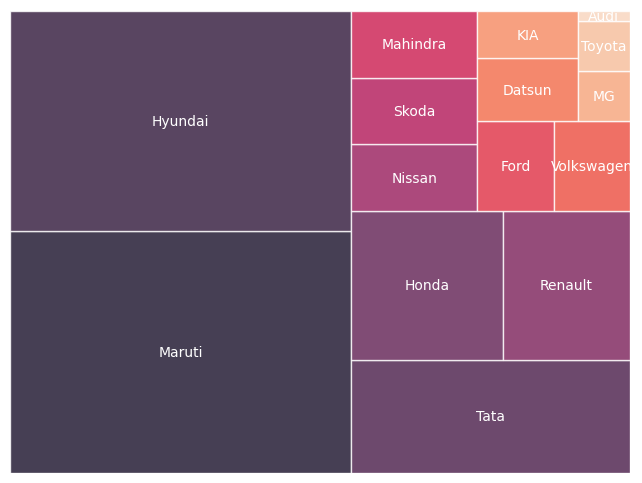

In [ ]:
plt.figure(figsize=(8,6))
squarify.plot(sizes=brand_counts['Count'],
              label=brand_counts['brand'],
              alpha=0.8, color=sns.color_palette("rocket", len(brand_counts)), edgecolor='white', linewidth=1,
              text_kwargs={'color':'white', 'fontsize':10})
plt.axis('off')
plt.savefig('brand_count.png', dpi=300, bbox_inches='tight')
plt.show()


<ipython-input-16-dae93ef5ec7f>:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=45, ha='right')


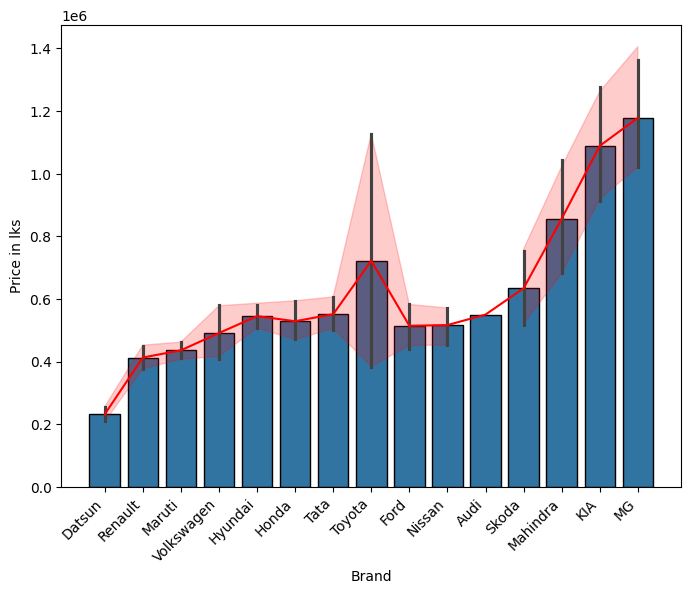

In [ ]:
plt.figure(figsize = (8,6))
sorted_brands = A_data.groupby('brand')['price'].median().sort_values().index
plot = sns.barplot(data = A_data,x = 'brand',y = 'price',order=sorted_brands,edgecolor = 'Black',linewidth =1)
sns.lineplot(data = A_data,x = 'brand',y = 'price',color = 'r')
plot.set_xlabel('Brand')
plot.set_ylabel('Price in lks')
plot.set_xticklabels(plot.get_xticklabels(), rotation=45, ha='right')
plt.savefig('price_brand.png', dpi=300, bbox_inches='tight')

###  2. What is the relationship between kilometers driven and price?

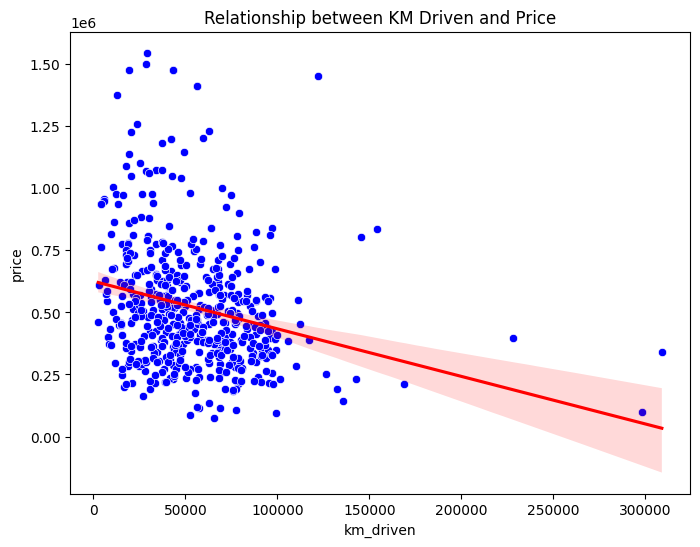

In [ ]:
plt.figure(figsize = (8,6))
plot = sns.scatterplot(data = A_data,x = 'km_driven',y = 'price',color = 'b')
sns.regplot(data = A_data,x = 'km_driven',y = 'price',scatter=False,color = 'red')
plt.title('Relationship between KM Driven and Price')
plt.savefig('Relationship between KM Driven and Price.png', dpi=300, bbox_inches='tight')

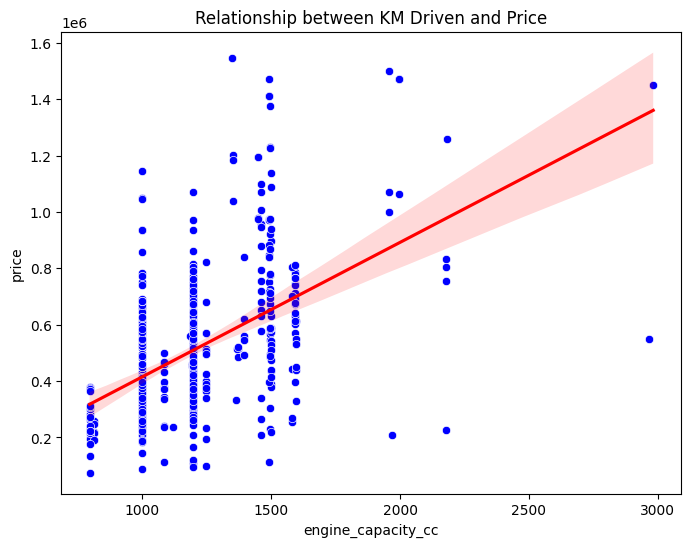

In [ ]:
plt.figure(figsize = (8,6))
plot = sns.scatterplot(data = A_data,x = 'engine_capacity_cc',y = 'price',color = 'b')
sns.regplot(data = A_data,x = 'engine_capacity_cc',y = 'price',scatter=False,color = 'red')
plt.title('Relationship between KM Driven and Price')
plt.savefig('Relationship between engine capacity and Price.png', dpi=300, bbox_inches='tight')

### 3. How does fuel type affect resale price and demand?

<ipython-input-18-6815f2b45aca>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = A_data,x = 'fuel',y = 'price',palette='husl',edgecolor = 'Black',linewidth =1)


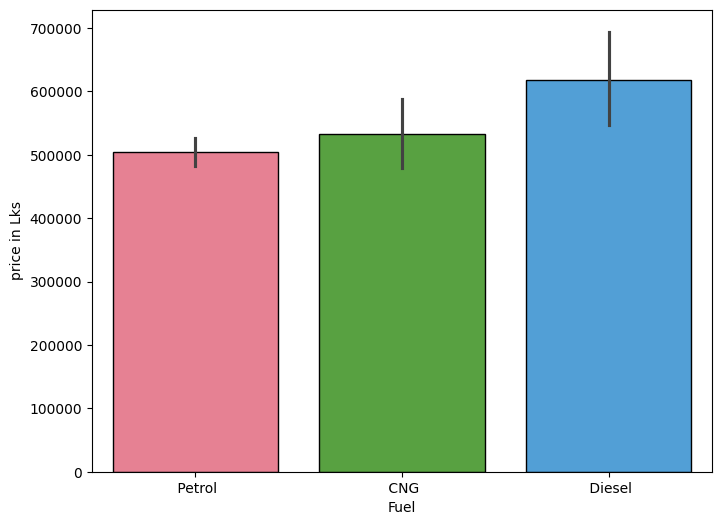

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(data = A_data,x = 'fuel',y = 'price',palette='husl',edgecolor = 'Black',linewidth =1)
plt.xlabel("Fuel")
plt.ylabel("price in Lks")
plt.savefig('Relationship between fuel and Price.png', dpi=300, bbox_inches='tight')

<ipython-input-49-365cb5f56ee7>:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
<ipython-input-49-365cb5f56ee7>:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
<ipython-input-49-365cb5f56ee7>:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


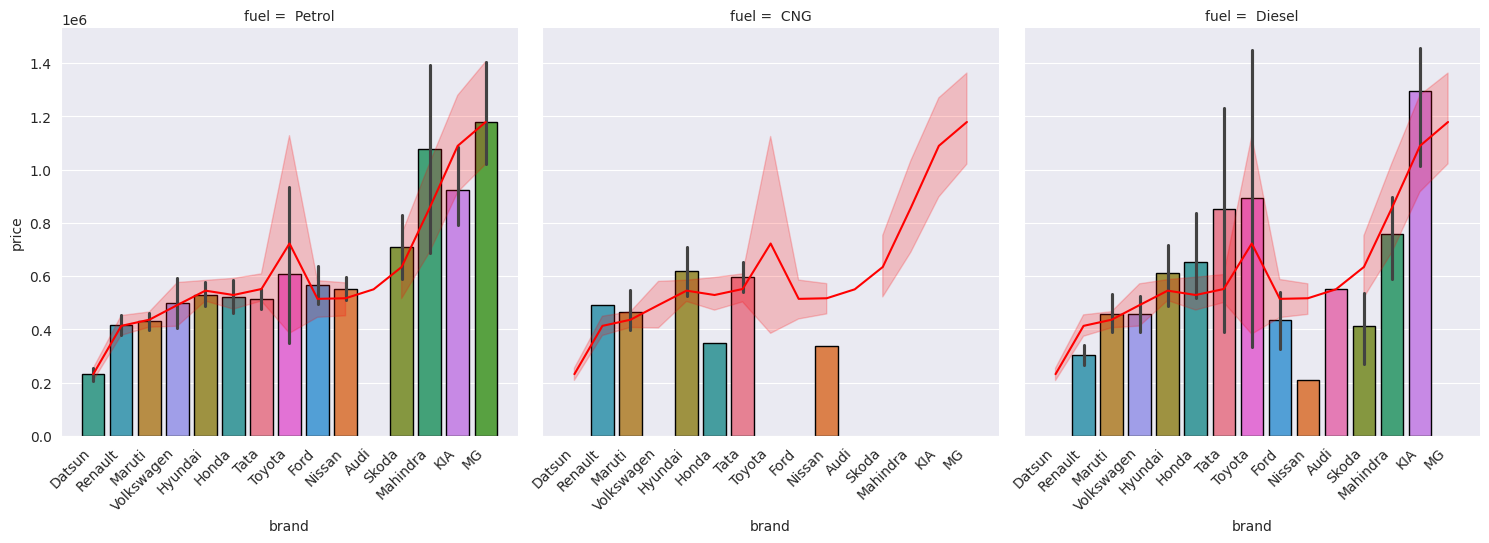

In [ ]:
sorted_brands = A_data.groupby('brand')['price'].median().sort_values().index
g = sns.catplot(data=A_data, x = 'brand', y='price', col='fuel', kind='bar',hue ='brand',order=sorted_brands,edgecolor = 'Black',linewidth =1)
for ax in g.axes.flat:
    sns.lineplot(data = A_data,x = 'brand',y = 'price',color = 'r', ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.savefig('Relationship between fuel and Price 2.png', dpi=300, bbox_inches='tight')
plt.show()

### 4. Do automatic cars have higher resale value than manual ones?

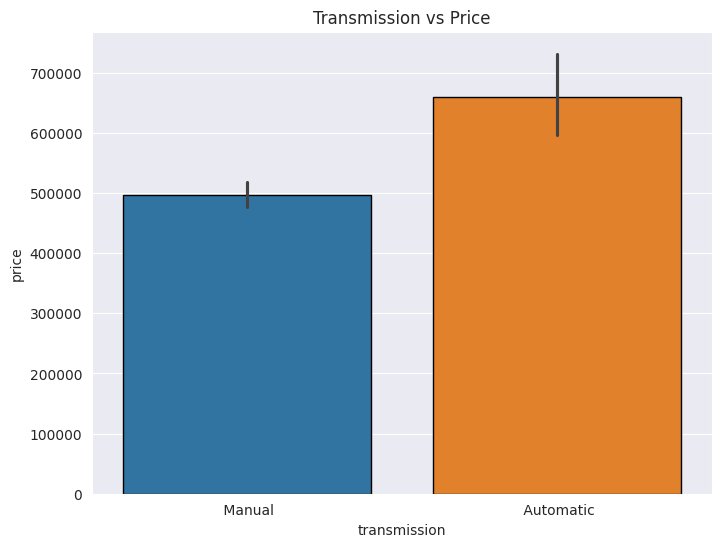

In [ ]:
plt.figure(figsize = (8,6))
sns.barplot(data = A_data,x = 'transmission',y = 'price', hue = 'transmission',edgecolor = 'Black',linewidth =1)
plt.title('Transmission vs Price')
plt.savefig('transmission and Price.png', dpi=300, bbox_inches='tight')

###  5. How does ownership history (1st, 2nd, etc.) affect the price?

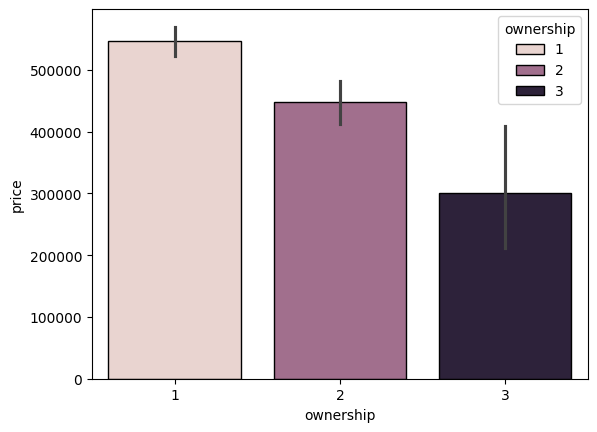

In [ ]:
sns.barplot(data = A_data,x = 'ownership',y = 'price',hue = 'ownership',edgecolor = 'black',linewidth = 1)
plt.savefig('ownership vs price.jpg',dpi = 400)

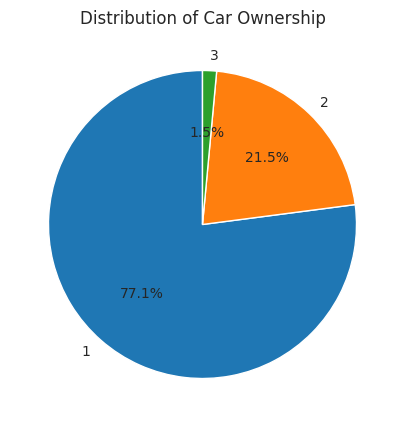

In [ ]:
ownership_counts = A_data['ownership'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(ownership_counts, labels=ownership_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Car Ownership')
plt.savefig('Distribution of Car Ownership',dpi = 400)
plt.show()

### 6. How does the presence of insurance affect resale value?

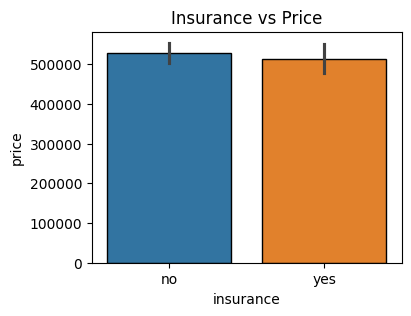

In [ ]:
plt.figure(figsize=(4,3))
sns.barplot(data= A_data,x = 'insurance', y = 'price',hue = 'insurance',edgecolor = 'Black',linewidth =1)
plt.title('Insurance vs Price')
plt.savefig('Insurance vs Price.jpg',dpi = 300,bbox_inches = 'tight')

### Correlation plot between numaric data

In [ ]:
A_data.insurance =[1 if i == 'yes' else 0 for i in A_data.insurance]

In [ ]:
A_data.insurance.value_counts()

,count
insurance,
0,336
1,209


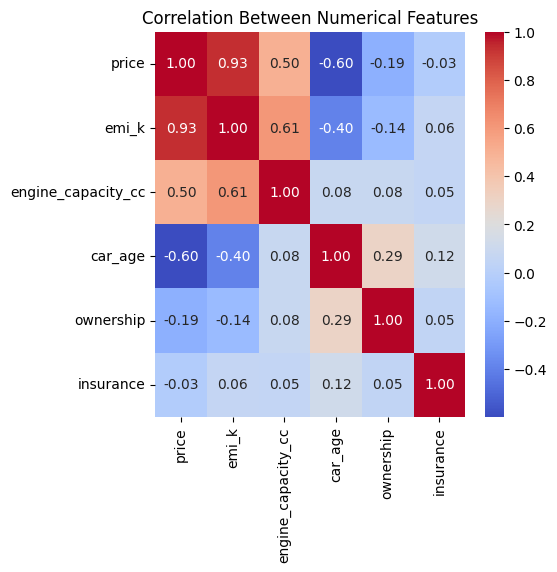

In [ ]:
plt.figure(figsize=(5,5))
corrl=A_data[['price', 'emi_k', 'engine_capacity_cc','car_age','ownership','insurance']].corr()
sns.heatmap(corrl,annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Between Numerical Features")
plt.savefig("corrl.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
avg_price_age=A_data.groupby('car_age')['price'].mean().reset_index()

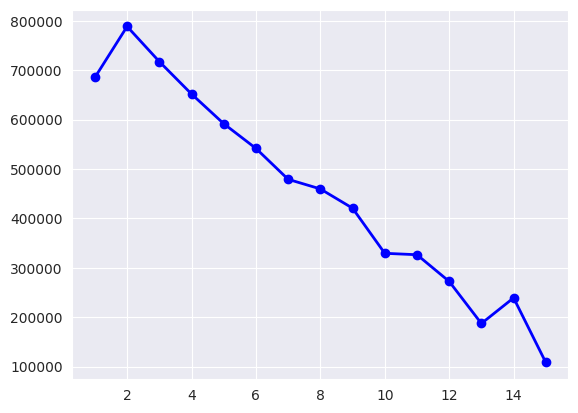

In [ ]:
sns.set_style("darkgrid")
plt.plot( 'car_age', 'price', data=avg_price_age, marker='o', color='blue',linewidth =2)
plt.savefig('car_age vs price.jpg',dpi = 400)
plt.show()